## Simulating SNIa with skysurvey
In this notebook, we study Supernovae Ia (SNIa).
First, we do without extinction and no gaussian noise.

Use cartopy and these instructions to visualise locations
https://skysurvey.readthedocs.io/en/latest/howto/target_and_skyarea.html

In [1]:
# import required packages:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import lightcurve
import lsst_functions
from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility

# import cosmology parameters
import sncosmo
from params import p_cosmology

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"] #note: lightcurve.py uses "redshift" 

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/home/denzelgoh/TransientSimulation/transient_rates.py:200: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  N [t^{-1}] = \int_0^{z_max} R(z)/(1+z) dV/dz dz


Load LSST as opsim (to be retrieved from the website: ). Note that the filesizes can be large 
If you want to choose only one band: band IN ('g') AND night < ...

In LSST opsim, the filters have an additional suffixes e.g. _6. For ease of coding, we replace the str using regex.

Note, unless you have sufficient processing power, loading lsst from opsim will crash VScode above 500 nights.
You would need to use a cluster to make the datasets and then reload the dataset after.

In [3]:
opsim_path = "baseline_v5.3.5_10yrs.db" # provide fullpath
# opsim_path = "Surveys/baseline_v5.3.5_10yrs.db:Zone.Identifier"
lsst = skysurvey.LSST.from_opsim(opsim_path, sql_where="night < 365")
# Remove the suffix.
lsst.data["band"] = (lsst.data["band"].str.replace(r"_\d+$", "", regex=True))
lsst.data["band"].unique()

<ArrowStringArray>
['lsstu', 'lsstr', 'lsstg', 'lssti', 'lsstz', 'lssty']
Length: 6, dtype: str

In [4]:
#  llod the date range across all the nights
from astropy.time import Time
tmin, tmax = lsst.date_range
print(f"Start: {Time(tmin, format='mjd').iso}")
print(f"End:   {Time(tmax, format='mjd').iso}")
print(f"Duration: {(tmax - tmin)/365.25:.1f} years")
lsst.date_range

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years


(np.float32(61208.203), np.float32(61566.074))

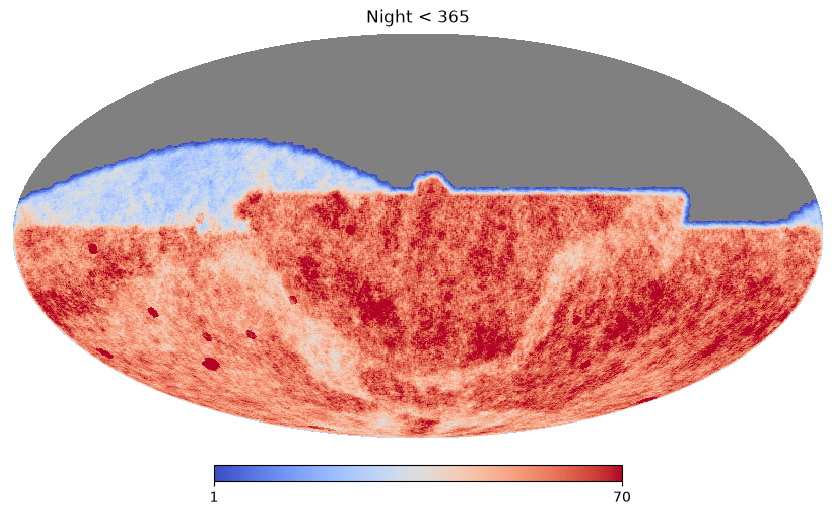

In [ ]:
# uncomment the following if you want to see the field coverage for your given opsim
coverage = lsst.get_fieldcoverage()
lsst.show(vmin=0, vmax=coverage.quantile(0.95), cmap="coolwarm", title = f'Night < 365')
# lsst.data # gives all info about the observation over all the nights (e.g skynoise and in what band). Returns pandas.df
# average over southern sky. could also take average below 30 deg dec --> we dk what new info we will get
# but we will in principle be simulating more sources

To look at observations across all filters in a given field id, use:
<code> select_fieldid = (lsst.data['fieldid'] == 336769) </code>
<code> lsst.data[select_fieldid] </code>

When generating a population, we always use these three back-to-back:
Theoretical lightcurves are simulated from phase [-20, 50], which are days w.r.t peak time. Observations of the target in that particilar field are made at later dates too (but are less likely to have SNR > 5.)

Because we are looking at $\nu$ sources and SNIa are not expected. But SNIa are useful for cosmo studies and the background of transients that we detect

2 completeness we can compute:

simulated vs detected
Until z = 10. We will detect until here. Total detected over the total . can make a fancy plot (with shaded until z = 1.0). We want a value of how many in full universe (4 pi u sr)

In [121]:
snia_dict = generate_snia_dict(redshift = None, ra = None, dec = None, x1 = None, t0 = None, magabs = None, c = None)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = lsst_bands, in_mag = False, N_tot = 1000, tstart = tmin -100, tstop = tmax, zp=30, plot_curve = False, return_values = True, return_models = True, verbose = False)

All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x7545390d0250>, 'kwargs': {'N': 1000, 'R_z': <function R_SFR at 0x754573eb4720>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x754578ff4b40>, 'kwargs': {'dec_range': [-90, 90]}}}


Essential functions:

skysurvey.Target.core.data.loc[index]
- To see a pd.Series of the data specific target transient of a particular index, use .loc[index]. (Note: using .iloc[5] will give the 5th target regardless of index number)

plot_lightcurve() (from <code>lightcurve.py</code>)
- uses the lightcurve times + flux values to plot theoretical lightcurves for a given object. Useful for comparing with theoretical flux/mag limits.

Once you simulated N_tot supernovae, the <code> .from_targets_and_survey() </code> function simulates the observation plan and sees if our SN are visible.

Functions:

- <code>skysurvey.dataset.get_target_lightcurve(self, index, detection=None, phase_range=None)</code> gives a dataframe of diff index_obs with columns: field params.
- <code>skysurvey.dataset.get_data</code> gives a dataframe of obs of a particular index. You can filter depending on <code>detection = bool or None.</code>
- <code>lightcurve.show_target_lightcurve()</code>: Shows theoretical lightcurve of one index + simulated observations from skysurvey.

In [122]:
snia_models.data

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.700707,0.105,0.048,61500.417969,346.121521,47.960129,-19.300570,23.911772,salt2
1,0.861902,-1.365,0.175,61392.175781,110.385223,-18.600637,-18.650341,25.112391,salt2
2,0.699017,0.715,-0.060,61129.906250,139.248260,-40.071537,-19.649546,23.556402,salt2
3,0.983801,-0.435,0.022,61498.460938,89.931503,-48.829399,-19.174831,24.941242,salt2
4,0.897729,-0.190,-0.031,61505.796875,315.373138,-26.039751,-19.349062,24.522348,salt2
...,...,...,...,...,...,...,...,...,...
995,0.449970,-0.740,0.129,61180.890625,84.023140,60.101952,-18.793343,23.260374,salt2
996,0.683019,0.300,-0.052,61296.214844,231.442856,-0.235292,-19.419779,23.724903,salt2
997,0.804188,-0.805,0.050,61189.496094,62.816822,13.283420,-18.998201,24.579853,salt2
998,0.997750,0.785,0.095,61242.269531,358.434753,10.145066,-19.306814,24.846916,salt2


(array([ 14.,  20.,  30.,  25.,  25.,  27.,  31.,  29.,  32.,  46.,  54.,
         60.,  59.,  67.,  75.,  63.,  80., 102.,  78.,  83.]),
 array([0.00191984, 0.05179485, 0.10166986, 0.15154487, 0.20141988,
        0.25129488, 0.3011699 , 0.35104489, 0.40091991, 0.45079494,
        0.50066996, 0.55054498, 0.60042   , 0.65029502, 0.70016998,
        0.750045  , 0.79992002, 0.84979504, 0.89967006, 0.94954503,
        0.99942005]),
 <BarContainer object of 20 artists>)

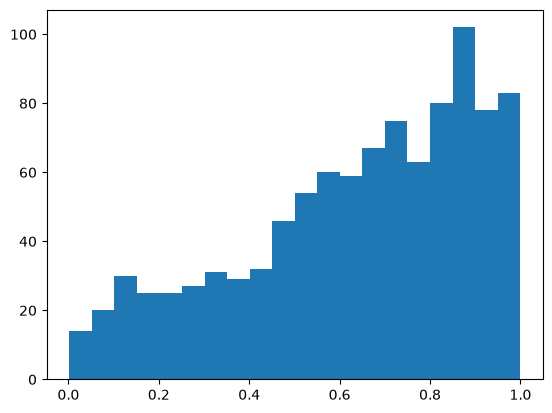

In [124]:
plt.hist(snia_models.data['z'], bins = 20)

In [13]:
from lsst_functions import exist_in_multiband_check, five_sigma_detection_multiband

In [ ]:
dset = skysurvey.DataSet.from_targets_and_survey(snia_models, lsst, progress_bar=True, discard_bands=True)

100%|██████████| 100/100 [00:04<00:00, 22.75it/s]


In [ ]:
from lsst_functions import get_number_detections_by_band
get_number_detections_by_band(dset, index=0, selection_criteria = {"total_points": 5, "n_filters": 2, "min_points_per_filter": 2})

{'lsstu': 0, 'lsstg': 1, 'lsstr': 5, 'lssti': 0, 'lsstz': 2, 'lssty': 0}

In [30]:
snia_models.data[["z", "x1", "c", "t0", "magabs", "magobs", "ra", "dec"]]

,z,x1,c,t0,magabs,magobs,ra,dec
0,0.512654,-0.150,0.109,61503.707031,-18.901951,23.489670,103.076302,-30.532385
1,0.810997,-1.415,0.218,61515.710938,-18.314121,25.286379,146.960632,-72.301414
2,0.904029,0.365,0.253,61454.523438,-18.437319,25.452763,208.252502,-15.331963
3,0.691448,0.590,0.021,61504.050781,-19.383808,23.793322,171.256134,-24.049080
4,0.475007,-1.640,-0.049,61255.792969,-19.089890,23.103756,329.799835,-7.989157
...,...,...,...,...,...,...,...,...
95,0.523263,-0.860,0.209,61487.707031,-18.512003,23.932957,355.547943,-68.139587
96,0.162115,-1.480,0.042,61510.609375,-18.971218,20.550648,96.288498,-35.023418
97,0.508864,-0.025,0.079,61440.468750,-18.970743,23.401575,351.708252,-37.545731
98,0.477317,1.485,0.116,61318.882812,-19.093790,23.112415,111.633469,-35.394733


In [120]:
# if you changed the lsst_functions.py file but do not want to restart the kerne;
import importlib
importlib.reload(lsst_functions)
importlib.reload(lightcurve)

<module 'lightcurve' from '/home/denzelgoh/TransientSimulation/lightcurve.py'>

In [5]:
# import our detection functions from lsst_functions.py

# function that filters out sources based on selection criteria
from lsst_functions import five_sigma_detection_multiband

# functions for number of sources detected
from lsst_functions import detectability_sources # to return a summary of detected sources.

# functions for number of alerts predicted
from lsst_functions import get_number_detections_allbands, n_detections_sources
from lsst_functions import get_total_alerts_from_survey_by_band # this is for if you want to loop through several redshifts. It stores for every redshift.


### Filtering observations

Here, we choose a common selection criteria of 5 total dets, min. 2 dets in 2 bands

In [ ]:
# set the N_tot and selection criteria. (5, 2, 2) is the default.
N_tot = 1000

from lsst_functions import set_selection_criteria
selection_criteria = set_selection_criteria(total_points=5, n_filters=2, min_points_per_filter=2)

In [ ]:
detected = get_total_alerts_from_survey_by_band(snia_param_list = snia_param_list, opsim = lsst, N_tot = N_tot, selection_criteria = selection_criteria)

Start: 2026-06-17 04:52:30.000
End:   2027-06-10 01:46:52.500
Duration: 1.0 years
All params input as None. Using default sampling functions, but with p_cosmology.
CUSTOM MODEL IS {'redshift': {'func': <function sample_redshift_from_Rz at 0x791b17799220>, 'kwargs': {'N': 1000, 'R_z': <function R_SFR at 0x791bc01d6fb0>, 'z_max': 1.0, 'p_cosmology': {'c': 299792.458, 'h0': 67.4, 'omega_M': 0.315, 'omega_K': 0, 'omega_L': 0.685, 'z_min': 0.0001, 'N_int_steps': 100, 'R0': {'SN Ia': <Quantity 23000. 1 / (yr Gpc3)>, 'SN CC': <Quantity 101000. 1 / (yr Gpc3)>, 'SN Ibc': <Quantity 101000. 1 / (yr Gpc3)>, 'SN II': <Quantity 101000. 1 / (yr Gpc3)>, 'TDE': <Quantity 8.e-07 1 / (yr Mpc3)>, 'KN': <Quantity 59.3 1 / (yr Gpc3)>}}}, 'as': 'z'}, 'radec': {'as': ['ra', 'dec'], 'func': <function random_radec at 0x791b1f904d50>, 'kwargs': {'dec_range': [-90, 0]}}}


100%|██████████| 1000/1000 [00:26<00:00, 37.28it/s]


In [ ]:
detected

In [ ]:
# add a column stating which redshift bin to be included in (for histogram purposes)
z_bins = np.arange(0, 1.01, 0.1) # set z bins
detected["z_bin"] = pd.cut(detected["z"],bins=z_bins,right=False)
detected[(detected['detected'] == True) & (detected['n_detections'] < 6)]

In [ ]:
detected_sources = detected[detected["detected"]]
n_sources = (detected_sources.groupby("z_bin", observed=True).size())
n_points = (detected_sources.groupby("z_bin", observed=True)["n_detections"].sum())

# print(n_sources)
print(n_points)

z_bin
[0.0, 0.1)    216
[0.1, 0.2)    447
[0.2, 0.3)    415
[0.3, 0.4)    417
[0.4, 0.5)    138
[0.5, 0.6)    243
[0.6, 0.7)     83
[0.7, 0.8)     30
[0.9, 1.0)      7
Name: n_detections, dtype: int64


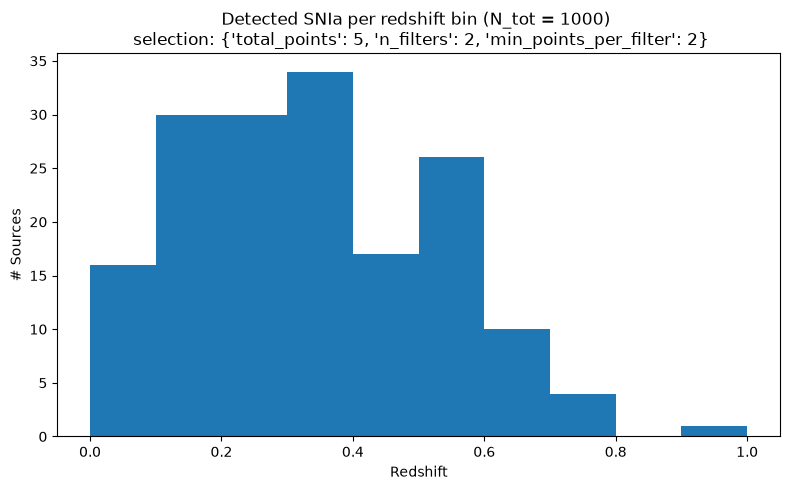

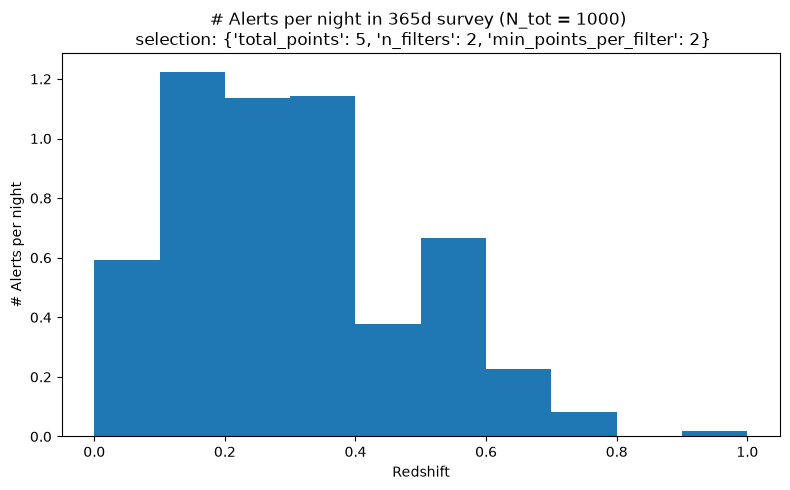

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(detected_sources["z"],bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa per redshift bin (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(detected_sources['z'], weights = detected_sources["n_detections"]/365, bins=z_bins)

plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"# Alerts per night in 365d survey (N_tot = {N_tot}) \n selection: {selection_criteria}")

plt.tight_layout()
plt.show()

In [82]:
detected = detected.drop(columns = ['z_bin'])


In [83]:
detected

,target,z,ra,dec,t0,detected,n_detections
0,0,0.637563,291.314972,-18.717270,61440.980469,False,0
1,1,0.413343,36.768787,-32.187431,61490.496094,False,0
2,2,0.430781,237.439255,-0.510577,61225.203125,True,6
3,3,0.805807,214.347961,-59.218273,61257.320312,False,0
4,4,0.394355,67.373337,-62.573044,61471.769531,False,0
...,...,...,...,...,...,...,...
995,995,0.167465,55.372765,-9.948995,61392.589844,True,13
996,996,0.517843,128.050018,-23.630953,61281.531250,False,0
997,997,0.715646,325.524658,-18.253996,61451.863281,False,0
998,998,0.991801,31.897120,-20.047499,61518.625000,False,0


In [ ]:
# save to parquet
detected.to_parquet(
    "smallparquet.parquet",
    engine="pyarrow",
    compression="zstd",
    index=False
)

In [95]:
example = pd.read_parquet('SNParquets/test_parquet.parquet')
example

,target,z,ra,dec,t0,detected,n_detections
0,0,0.391595,137.598007,-27.899683,61451.925781,True,16
1,1,0.628783,291.860168,-0.813505,61426.632812,False,0
2,2,0.573308,248.084091,-81.774208,61449.066406,False,0
3,3,0.285084,271.158142,-14.354739,61192.343750,True,7
4,4,0.692918,328.366333,-1.830170,61162.875000,False,0
...,...,...,...,...,...,...,...
9995,9995,0.196232,84.348785,-15.727390,61270.667969,False,0
9996,9996,0.205392,172.949387,-51.370121,61555.171875,False,0
9997,9997,0.614645,15.414575,-45.277348,61403.656250,False,0
9998,9998,0.994361,224.058289,-9.600336,61220.714844,False,0


## Now simulate full SNIa population in a cluster.
Refer to <code>script_instructions.txt</code> for instructions on how to submit a population simulation

We have tested the simulations with a smaller population. Using R_z , we can expect to have 5646916 within $z \in [10^{-4}, 1.0]$

#### Once you have simulated the pop,  combine the parquets and load the combined parquets

In [6]:
from pathlib import Path
import pandas as pd

results_dir = Path("results_2")
parquet_file = results_dir / "detected_N100000_004.parquet"
# rsync uses scp under the hood but it will only copy new files by checking modification files
df_single = pd.read_parquet(parquet_file)
df_single

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,batch,target_global
0,0,0.644372,0.470,0.079,61332.273438,-19.081059,23.909796,316.292114,-17.157434,False,0,4,400000
1,1,0.785539,-1.980,0.054,61521.214844,-18.951317,24.564314,219.930466,-7.699664,False,0,4,400001
2,2,0.991301,-1.675,-0.014,61149.222656,-19.180946,24.955439,144.654037,-64.002022,False,0,4,400002
3,3,0.876031,0.400,0.273,61266.589844,-18.504875,25.301233,70.943970,-33.199173,False,0,4,400003
4,4,0.553320,-0.710,0.245,61485.921875,-18.433899,24.156857,335.133575,-52.444607,False,0,4,400004
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99995,0.507654,0.445,-0.068,61519.246094,-19.662416,22.703709,228.077835,-22.312979,True,10,4,499995
99996,99996,0.350818,0.750,0.069,61322.730469,-19.073214,22.344435,36.317787,-29.377520,True,16,4,499996
99997,99997,0.827226,-0.525,-0.019,61429.074219,-19.234795,24.418472,127.217743,-41.040302,False,0,4,499997
99998,99998,0.009089,-1.520,0.011,61399.019531,-19.100056,13.940042,191.781509,-61.861729,True,8,4,499998


In [ ]:
# combine all parquets into one big parquet (about 200 MB for 5.7 million SNIa)
from pathlib import Path
import pandas as pd
import numpy as np

# Uncomment below if you want to creat a combined parquet
# change what is inside Path depending on folder name
files = sorted(Path("results_2").glob("detected_N*.parquet"))
dfs = [pd.read_parquet(f) for f in files]

combined = pd.concat(dfs, ignore_index=True)

# If your batch job already created a unique target field:
if "target_global" in combined.columns:
    combined["target"] = combined["target_global"]

# Otherwise, force a new unique index:
else:
    combined = combined.reset_index(drop=True)
    combined["target"] = np.arange(len(combined))

# CHANGE THIS depending on folder name
combined.to_parquet("results_2/combined_detected.parquet", engine="pyarrow", compression="zstd", index=False)

In [7]:
# if you want to load an existing parquet / combined parquet:
combined = pd.read_parquet("results_2/combined_detected.parquet")

In [8]:
combined

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,batch,target_global
0,0,0.953984,-1.375,0.215,61167.109375,-18.339422,25.694361,9.585967,-64.264816,False,0,0,0
1,1,0.253597,0.300,0.220,61120.742188,-18.485870,22.120895,150.973709,-63.731087,False,0,0,1
2,2,0.762401,-0.240,0.516,61152.152344,-17.709721,25.726435,169.780579,-14.977562,False,0,0,2
3,3,0.681929,0.890,-0.147,61260.835938,-19.760740,23.379719,54.404106,-24.840033,False,0,0,3
4,4,0.550750,-1.585,0.024,61345.093750,-18.874134,23.704449,285.872833,-5.934869,False,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5646901,5646901,0.454649,-1.800,0.257,61192.324219,-18.272926,23.807484,146.609192,-72.266273,False,0,56,5646901
5646902,5646902,0.610035,0.480,0.153,61405.226562,-18.779755,24.066893,269.215820,-29.798468,False,0,56,5646902
5646903,5646903,0.695077,0.585,0.040,61468.007812,-19.105999,24.084986,292.668610,-33.726574,False,0,56,5646903
5646904,5646904,0.915608,0.520,0.056,61236.796875,-19.233301,24.690769,156.467026,-57.232750,False,0,56,5646904


In [9]:
combined['z'].max()

np.float32(1.0)

In [70]:
from lsst_functions import add_zbin_column, get_nsources_nalerts_per_zbin
detected = add_zbin_column(combined, zbin_max = 1.0, zbin_size = 0.01, detected_only=True)
all_sources = add_zbin_column(combined, zbin_max = 1.0, zbin_size = 0.01, detected_only=False)


In [53]:
detected

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,batch,target_global,z_bin
14,14,0.105411,0.730,0.055,61290.640625,-19.277678,19.231716,337.633911,-21.705894,True,22,0,14,"[0.1, 0.11)"
20,20,0.253087,-1.640,0.115,61234.589844,-18.765699,21.836102,218.904388,-40.923931,True,8,0,20,"[0.25, 0.26)"
26,26,0.727465,1.355,-0.087,61484.246094,-19.840202,23.471441,233.741974,-2.317462,True,13,0,26,"[0.72, 0.73)"
33,33,0.027078,-1.610,-0.193,61225.980469,-19.779535,15.660134,253.391098,-33.891777,True,15,0,33,"[0.02, 0.03)"
41,41,0.277825,-1.310,0.092,61457.980469,-19.030867,21.801775,233.052231,-11.264502,True,21,0,41,"[0.27, 0.28)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5646873,5646873,0.199762,0.440,-0.001,61337.703125,-19.328060,20.695589,82.773758,-35.895863,True,26,56,5646873,"[0.19, 0.2)"
5646884,5646884,0.415573,0.290,-0.028,61492.511719,-19.378910,22.470297,316.701263,-48.996239,True,5,56,5646884,"[0.41, 0.42)"
5646885,5646885,0.290674,-0.075,0.082,61402.558594,-19.015642,21.929527,22.884123,-62.525391,True,6,56,5646885,"[0.29, 0.3)"
5646894,5646894,0.029517,0.615,-0.116,61245.230469,-19.786652,15.844252,234.589523,-26.728207,True,12,56,5646894,"[0.02, 0.03)"


In [54]:
detected.copy().sort_values('n_detections', ascending=False).head(10)

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,batch,target_global,z_bin
2502929,2502929,0.200062,0.425,-0.104,61368.484375,-19.744890,20.282393,52.442337,-26.743160,True,188,25,2502929,"[0.2, 0.21)"
777417,777417,0.080783,0.625,-0.032,61329.531250,-19.484222,18.411573,52.897915,-26.973156,True,185,7,777417,"[0.08, 0.09)"
3468857,3468857,0.194862,1.555,-0.003,61312.507812,-19.675247,20.288328,35.224182,-4.423098,True,184,34,3468857,"[0.19, 0.2)"
34514,34514,0.079203,0.185,-0.078,61390.796875,-19.532305,18.318264,53.947178,-27.853643,True,183,0,34514,"[0.07, 0.08)"
3647615,3647615,0.192413,0.290,-0.121,61339.917969,-19.806622,20.126390,36.136181,-4.732625,True,180,36,3647615,"[0.19, 0.2)"
4396649,4396649,0.242148,0.690,-0.098,61330.000000,-19.562376,20.930649,53.828354,-28.281076,True,178,43,4396649,"[0.24, 0.25)"
2900614,2900614,0.199352,0.855,0.021,61348.128906,-19.419800,20.598877,8.669572,-44.882767,True,177,29,2900614,"[0.19, 0.2)"
1937438,1937438,0.197702,0.330,0.133,61352.648438,-19.060089,20.938473,52.082058,-27.087378,True,176,19,1937438,"[0.19, 0.2)"
2157355,2157355,0.204562,0.785,-0.027,61308.144531,-19.380623,20.700567,8.501348,-43.285461,True,176,21,2157355,"[0.2, 0.21)"
3831753,3831753,0.021948,0.450,-0.028,61418.777344,-19.471228,15.504139,51.760143,-28.892494,True,175,38,3831753,"[0.02, 0.03)"


In [71]:
n_sources, n_alerts = get_nsources_nalerts_per_zbin(detected)
n_sources, n_alerts

(z_bin
 [0.0, 0.01)     7056
 [0.01, 0.02)    7178
 [0.02, 0.03)    8397
 [0.03, 0.04)    8706
 [0.04, 0.05)    8683
                 ... 
 [0.95, 0.96)      30
 [0.96, 0.97)      34
 [0.97, 0.98)      34
 [0.98, 0.99)      23
 [0.99, 1.0)       13
 Length: 100, dtype: int64,
 z_bin
 [0.0, 0.01)      92314
 [0.01, 0.02)     94967
 [0.02, 0.03)    131414
 [0.03, 0.04)    137881
 [0.04, 0.05)    137924
                  ...  
 [0.95, 0.96)       187
 [0.96, 0.97)       231
 [0.97, 0.98)       217
 [0.98, 0.99)       151
 [0.99, 1.0)         91
 Name: n_detections, Length: 100, dtype: int64)

In [72]:
n_sources_all, n_alerts_all = get_nsources_nalerts_per_zbin(all_sources)
n_sources_all, n_alerts_all

(z_bin
 [0.0, 0.01)      18453
 [0.01, 0.02)     18978
 [0.02, 0.03)     19519
 [0.03, 0.04)     20089
 [0.04, 0.05)     20450
                  ...  
 [0.95, 0.96)    100624
 [0.96, 0.97)    102641
 [0.97, 0.98)    103116
 [0.98, 0.99)    103810
 [0.99, 1.0)     105584
 Length: 100, dtype: int64,
 z_bin
 [0.0, 0.01)      92314
 [0.01, 0.02)     94967
 [0.02, 0.03)    131414
 [0.03, 0.04)    137881
 [0.04, 0.05)    137924
                  ...  
 [0.95, 0.96)       187
 [0.96, 0.97)       231
 [0.97, 0.98)       217
 [0.98, 0.99)       151
 [0.99, 1.0)         91
 Name: n_detections, Length: 100, dtype: int64)

In [57]:
n_sources.index

CategoricalIndex([ [0.0, 0.01), [0.01, 0.02), [0.02, 0.03), [0.03, 0.04),
                  [0.04, 0.05), [0.05, 0.06), [0.06, 0.07), [0.07, 0.08),
                  [0.08, 0.09),  [0.09, 0.1),  [0.1, 0.11), [0.11, 0.12),
                  [0.12, 0.13), [0.13, 0.14), [0.14, 0.15), [0.15, 0.16),
                  [0.16, 0.17), [0.17, 0.18), [0.18, 0.19),  [0.19, 0.2),
                   [0.2, 0.21), [0.21, 0.22), [0.22, 0.23), [0.23, 0.24),
                  [0.24, 0.25), [0.25, 0.26), [0.26, 0.27), [0.27, 0.28),
                  [0.28, 0.29),  [0.29, 0.3),  [0.3, 0.31), [0.31, 0.32),
                  [0.32, 0.33), [0.33, 0.34), [0.34, 0.35), [0.35, 0.36),
                  [0.36, 0.37), [0.37, 0.38), [0.38, 0.39),  [0.39, 0.4),
                   [0.4, 0.41), [0.41, 0.42), [0.42, 0.43), [0.43, 0.44),
                  [0.44, 0.45), [0.45, 0.46), [0.46, 0.47), [0.47, 0.48),
                  [0.48, 0.49),  [0.49, 0.5),  [0.5, 0.51), [0.51, 0.52),
                  [0.52, 0.53), [0.53,

In [58]:
detected["n_detections"].values

array([22,  8, 13, ...,  6, 12,  5], shape=(742483,))

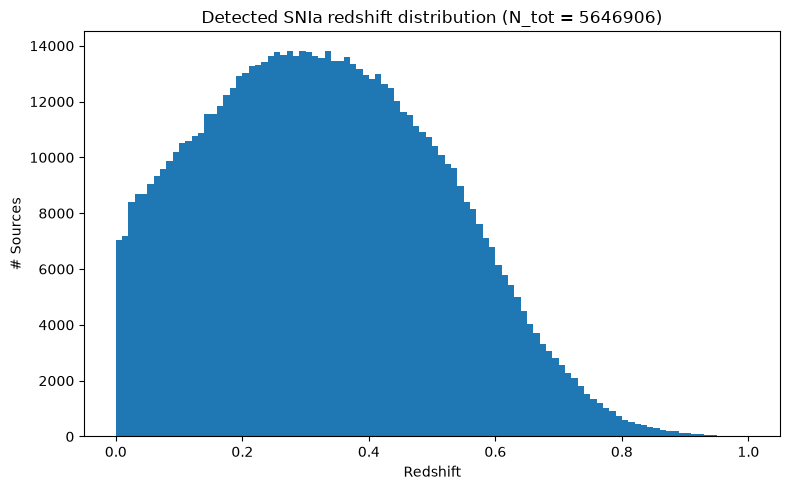

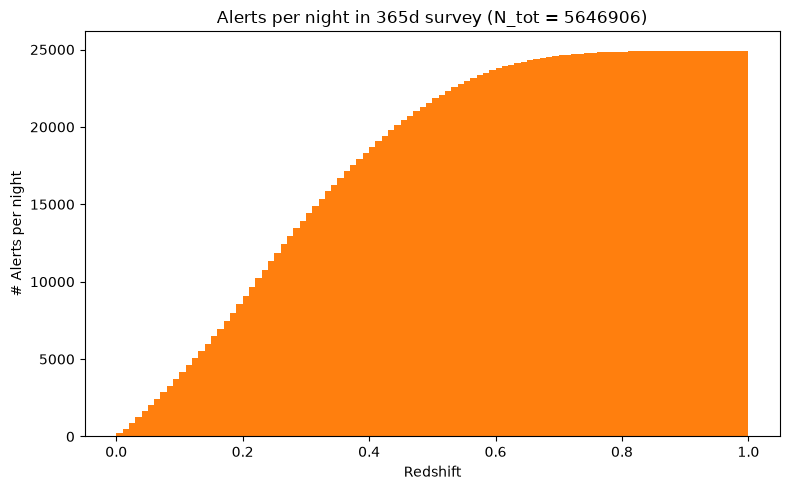

In [59]:
# 1) number of detected sources per z-bin
N_tot = len(combined)

plt.figure(figsize=(8, 5))
plt.hist(detected["z"], bins=np.arange(0, 1.01, 0.01), color="tab:blue")
plt.xlabel("Redshift")
plt.ylabel("# Sources")
plt.title(f"Detected SNIa redshift distribution (N_tot = {N_tot})")
plt.tight_layout()
plt.show()

# 2) alerts per night per z-bin
plt.figure(figsize=(8, 5))
plt.hist(
    detected["z"],
    cumulative=True,
    bins=np.arange(0, 1.01, 0.01),
    weights=detected["n_detections"].values / 365.0,
    color="tab:orange"
)
plt.xlabel("Redshift")
plt.ylabel("# Alerts per night")
plt.title(f"Alerts per night in 365d survey (N_tot = {N_tot})")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, '# n sources over 365 days')

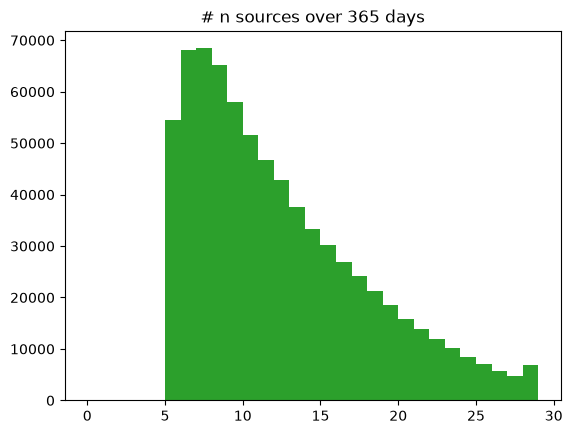

In [60]:
plt.hist(detected['n_detections'], bins = np.arange(0, 30, 1), color="tab:green")
plt.title('# n sources over 365 days')

In [ ]:
from astropy import units as u
from params import p_cosmology

import astropy.cosmology as acosmo
cosmo = acosmo.LambdaCDM(H0=p_cosmology['h0']* u.km / u.s / u.Mpc, 
                         Om0=p_cosmology['omega_M'],
                        Ode0=p_cosmology['omega_L'])

dV = cosmo.differential_comoving_volume(0.10) - cosmo.differential_comoving_volume(0.09)
dV


<Quantity 1.44975432e+08 Mpc3 / sr>

In [ ]:
def get_shell_volume(z_min, z_max, cosmo=cosmo):
    # i don't think we need to use this function...
    dV = cosmo.comoving_volume(z_max) - cosmo.comoving_volume(z_min)
    return dV.to(u.Mpc**3 / u.sr)

In [ ]:
dVdz = cosmo.comoving_volume(np.arange(0, 1.01, 0.1))
dVdz

<Quantity [0.00000000e+00, 3.42681741e+08, 2.53951701e+09, 7.91794120e+09,
           1.73051656e+10, 3.11256781e+10, 4.94999116e+10, 7.23327651e+10,
           9.93866712e+10, 1.30338209e+11, 1.64819739e+11] Mpc3>

In [ ]:
shell_volumes = np.diff(cosmo.comoving_volume(np.arange(0, 1.01, 0.01))).to(u.Mpc**3)
shell_volumes #in Mpc^3

<Quantity [3.66001963e+05, 2.54114463e+06, 6.83412721e+06, 1.31826463e+07,
           2.15246821e+07, 3.17985555e+07, 4.39429837e+07, 5.78971324e+07,
           7.36006670e+07, 9.09938004e+07, 1.10017339e+08, 1.30612728e+08,
           1.52722088e+08, 1.76288258e+08, 2.01254831e+08, 2.27566187e+08,
           2.55167521e+08, 2.84004881e+08, 3.14025185e+08, 3.45176251e+08,
           3.77406817e+08, 4.10666564e+08, 4.44906127e+08, 4.80077120e+08,
           5.16132139e+08, 5.53024783e+08, 5.90709657e+08, 6.29142384e+08,
           6.68279607e+08, 7.08078996e+08, 7.48499251e+08, 7.89500100e+08,
           8.31042300e+08, 8.73087636e+08, 9.15598915e+08, 9.58539966e+08,
           1.00187563e+09, 1.04557175e+09, 1.08959517e+09, 1.13391373e+09,
           1.17849623e+09, 1.22331246e+09, 1.26833315e+09, 1.31352999e+09,
           1.35887557e+09, 1.40434344e+09, 1.44990802e+09, 1.49554463e+09,
           1.54122946e+09, 1.58693956e+09, 1.63265281e+09, 1.67834794e+09,
           1.72400445e+09

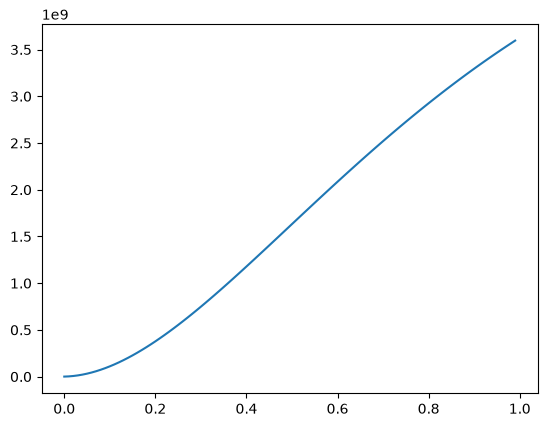

In [112]:
plt.plot(np.arange(0, 1, 0.01), shell_volumes)

In [63]:
all_sources

,target,z,x1,c,t0,magabs,magobs,ra,dec,detected,n_detections,batch,target_global,z_bin
0,0,0.953984,-1.375,0.215,61167.109375,-18.339422,25.694361,9.585967,-64.264816,False,0,0,0,"[0.95, 0.96)"
1,1,0.253597,0.300,0.220,61120.742188,-18.485870,22.120895,150.973709,-63.731087,False,0,0,1,"[0.25, 0.26)"
2,2,0.762401,-0.240,0.516,61152.152344,-17.709721,25.726435,169.780579,-14.977562,False,0,0,2,"[0.76, 0.77)"
3,3,0.681929,0.890,-0.147,61260.835938,-19.760740,23.379719,54.404106,-24.840033,False,0,0,3,"[0.68, 0.69)"
4,4,0.550750,-1.585,0.024,61345.093750,-18.874134,23.704449,285.872833,-5.934869,False,0,0,4,"[0.55, 0.56)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5646901,5646901,0.454649,-1.800,0.257,61192.324219,-18.272926,23.807484,146.609192,-72.266273,False,0,56,5646901,"[0.45, 0.46)"
5646902,5646902,0.610035,0.480,0.153,61405.226562,-18.779755,24.066893,269.215820,-29.798468,False,0,56,5646902,"[0.61, 0.62)"
5646903,5646903,0.695077,0.585,0.040,61468.007812,-19.105999,24.084986,292.668610,-33.726574,False,0,56,5646903,"[0.69, 0.7)"
5646904,5646904,0.915608,0.520,0.056,61236.796875,-19.233301,24.690769,156.467026,-57.232750,False,0,56,5646904,"[0.91, 0.92)"


In [73]:
Rz_bin_counts = n_sources.values/shell_volumes/365 #Mpc^-3 yr^-1
Rz_bin_counts_all = n_sources_all.values/shell_volumes/365 #Mpc^-3 yr^-1
Rz_bin_counts[50:55], Rz_bin_counts_all[50:55]

(<Quantity [1.74940095e-08, 1.64414779e-08, 1.55038852e-08, 1.48814459e-08,
            1.35497765e-08] 1 / Mpc3>,
 <Quantity [9.07590893e-08, 8.93262623e-08, 8.87834213e-08, 8.83907106e-08,
            8.69981086e-08] 1 / Mpc3>)

In [78]:
n_sources.index

CategoricalIndex([ [0.0, 0.01), [0.01, 0.02), [0.02, 0.03), [0.03, 0.04),
                  [0.04, 0.05), [0.05, 0.06), [0.06, 0.07), [0.07, 0.08),
                  [0.08, 0.09),  [0.09, 0.1),  [0.1, 0.11), [0.11, 0.12),
                  [0.12, 0.13), [0.13, 0.14), [0.14, 0.15), [0.15, 0.16),
                  [0.16, 0.17), [0.17, 0.18), [0.18, 0.19),  [0.19, 0.2),
                   [0.2, 0.21), [0.21, 0.22), [0.22, 0.23), [0.23, 0.24),
                  [0.24, 0.25), [0.25, 0.26), [0.26, 0.27), [0.27, 0.28),
                  [0.28, 0.29),  [0.29, 0.3),  [0.3, 0.31), [0.31, 0.32),
                  [0.32, 0.33), [0.33, 0.34), [0.34, 0.35), [0.35, 0.36),
                  [0.36, 0.37), [0.37, 0.38), [0.38, 0.39),  [0.39, 0.4),
                   [0.4, 0.41), [0.41, 0.42), [0.42, 0.43), [0.43, 0.44),
                  [0.44, 0.45), [0.45, 0.46), [0.46, 0.47), [0.47, 0.48),
                  [0.48, 0.49),  [0.49, 0.5),  [0.5, 0.51), [0.51, 0.52),
                  [0.52, 0.53), [0.53,

(0.0, 1.1)

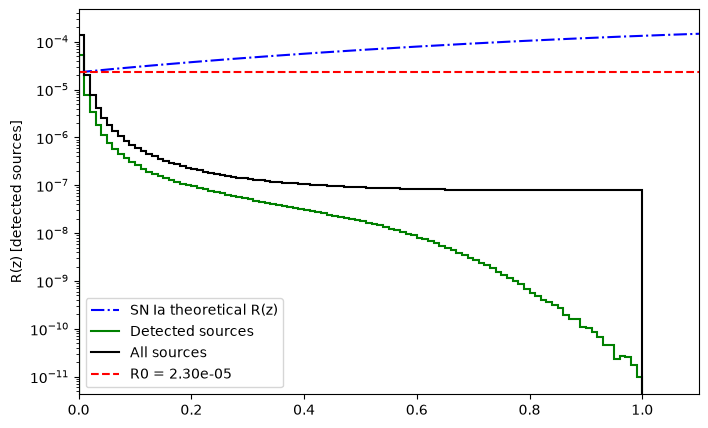

In [ ]:
# zmin here is 1e-4
plt.figure(figsize = (8,5))
from transient_rates import R_SFR
z_range = np.linspace(0, 10, 1000)
intervals = n_sources.index
z_edges = np.array([intervals[0].left] + [interval.right for interval in intervals])
R_z = R_SFR(z_range, R0=p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr))

plt.plot(z_range, R_z, color='blue', linestyle = '-.', label='SN Ia theoretical R(z)')
plt.stairs(Rz_bin_counts, z_edges, label='Detected sources', color='green', lw = 1.5)
plt.stairs(Rz_bin_counts_all, z_edges, label='All sources', color='k', lw = 1.5)
plt.yscale('log')
plt.ylabel('R(z) [detected sources]')
plt.axhline(p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr).value, color='r', linestyle='--', label='R0 = {:.2e}'.format(p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr).value))
# plt.xlim(0.0, 0.05)

plt.legend()
plt.xlim(0, 0.)
# plt.ylim(2.2e-5, 2.4e-5)
# plt.ylim(0,0.1e7)


(array([ 18625.,  18972.,  19525.,  20092.,  20445.,  20917.,  21734.,
         22300.,  22817.,  23376.,  23958.,  24663.,  24894.,  25707.,
         26488.,  27237.,  27512.,  28338.,  29002.,  29514.,  30090.,
         30654.,  31183.,  32202.,  32819.,  33647.,  34231.,  34901.,
         35193.,  36394.,  37614.,  37812.,  38296.,  39599.,  39997.,
         41126.,  41758.,  42573.,  43772.,  44010.,  45262.,  45907.,
         47227.,  48193.,  48576.,  49653.,  50026.,  51025.,  52114.,
         53162.,  54115.,  54672.,  55914.,  57065.,  57665.,  58579.,
         59605.,  60459.,  61400.,  62399.,  63702.,  64238.,  65515.,
         66260.,  67740.,  68614.,  69359.,  70259.,  71494.,  72925.,
         73879.,  74539.,  75407.,  77110.,  77684.,  79121.,  79722.,
         80987.,  82596.,  82871.,  84042.,  85538.,  86472.,  87862.,
         88413.,  89652.,  90845.,  92201.,  92946.,  94573.,  95453.,
         96084.,  97854.,  98476.,  99697., 100606., 102638., 103119.,
      

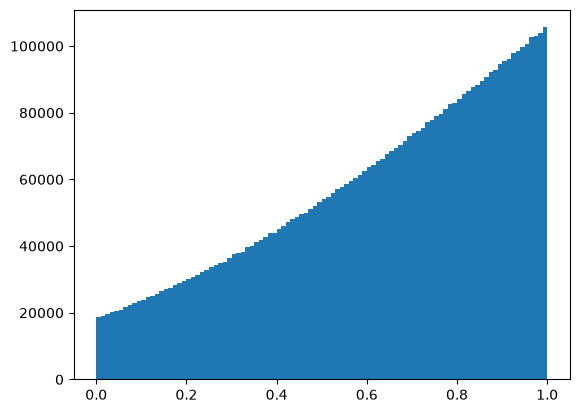

In [110]:
plt.hist(all_sources['z'], bins = 100)

In [ ]:
plt.plot(np.arange(0.01, 1.01, 0.01), total_Rz_bin_counts)
plt.yscale('log')
plt.ylabel('R(z) [detected sources]')
plt.axhline(p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr).value, color='r', linestyle='--', label='R0')

In [ ]:
print(f"Total alerts per night: {detected['n_detections'].sum() / 365}")

Total alerts per night: 31026.002739726027


In [ ]:
len(detected) / 365, len(combined)/365

(2511.068493150685, 15471.002739726027)

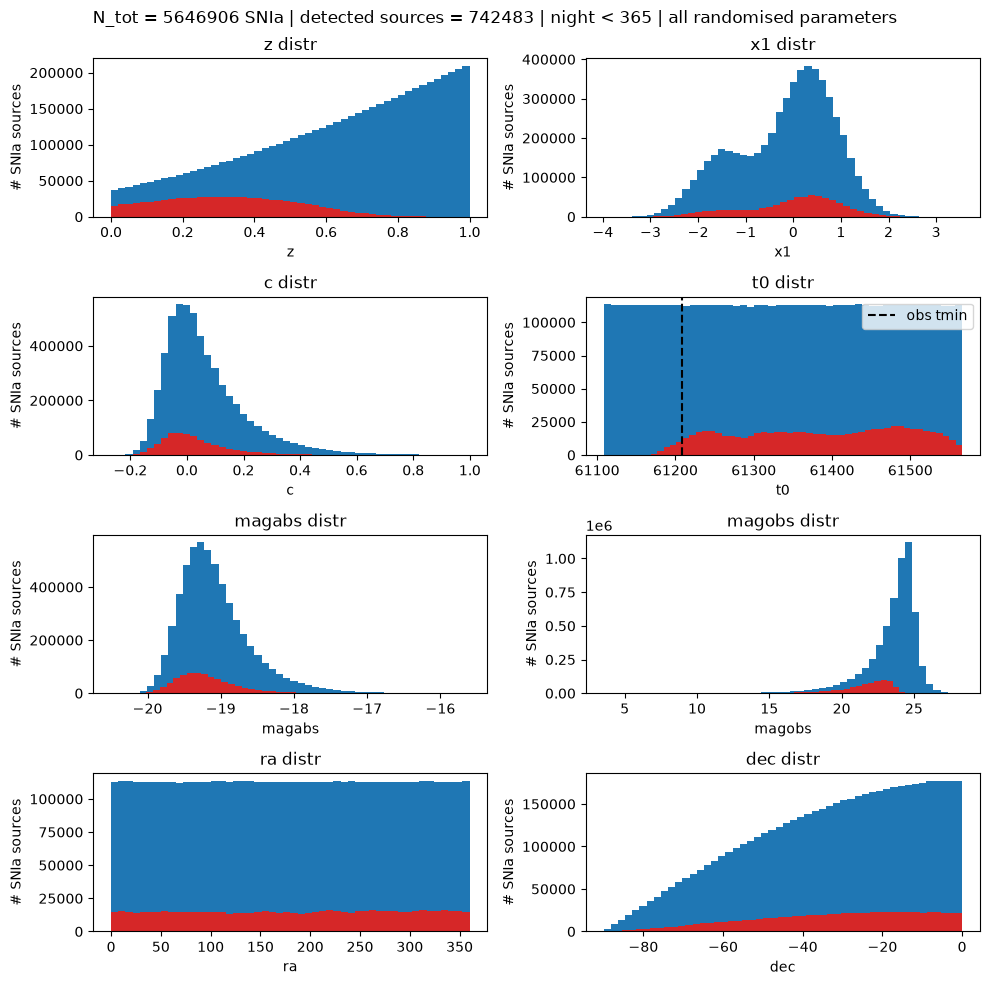

In [79]:
#perhaps this way, you don't need to specify bins?

detected_models = combined[combined['detected'] == True] # a df

params = ['z', 'x1', 'c', 't0', 'magabs', 'magobs', 'ra', 'dec']

fig, axs = plt.subplots(4, 2, figsize=(10, 10))

for ax, param in zip(axs.flat, params):
    ax.hist(combined[param], bins=50, color = 'tab:blue')
    ax.hist(detected_models[param], bins=50, color = 'tab:red')
    if param == 't0':
        ax.axvline(tmin, color = 'k', linestyle = '--', label = 'obs tmin')
        ax.legend()
    ax.set_xlabel(param)
    ax.set_ylabel("# SNIa sources")
    ax.set_title(f"{param} distr")

# Hide unused subplot
for ax in axs.flat[len(params):]:
    ax.set_visible(False)
plt.suptitle(f'N_tot = {N_tot} SNIa | detected sources = {len(detected_models)} | night < 365 | all randomised parameters')
plt.tight_layout()

plt.show()

### Checking that SNIa population aligns with observations

Redshift evolution of the underlying type Ia supernova stretch distributions: https://www.aanda.org/articles/aa/pdf/2021/05/aa38447-20.pdf
SNe Ia at higher redshift have a larger stretch (0.34 ± 0.10 at z ∼ 0.65) on average than those at lower redshift (−0.17 ± 0.10 at z ∼ 0.05), suggesting that the underlying stretch distribution evolves withredshift.

In [25]:
combined_highz = combined[(combined['z'] > 0.62) & (combined['z'] <= 0.68)]
combined_lowz = combined[(combined['z'] > 0.02) & (combined['z'] <= 0.08)]
combined_highz['x1'].describe(), combined_lowz['x1'].describe()

(count    407500.000000
 mean         -0.175570
 std           1.028694
 min          -3.985000
 25%          -0.925000
 50%           0.015000
 75%           0.585000
 max           3.160000
 Name: x1, dtype: float64,
 count    125624.000000
 mean         -0.175468
 std           1.028371
 min          -3.640000
 25%          -0.925000
 50%           0.015000
 75%           0.580000
 max           3.145000
 Name: x1, dtype: float64)

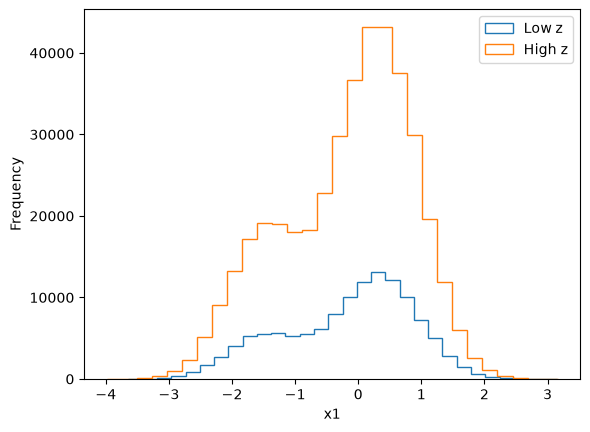

In [26]:
plt.hist(combined_lowz['x1'], histtype='step', label='Low z', color='tab:blue', bins=30)
plt.hist(combined_highz['x1'], histtype='step', label='High z', color='tab:orange', bins=30)
plt.xlabel('x1')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [28]:
combined['z'].max()

np.float32(1.0)